# 🚗 DATA DRIFT — Highway Traffic Analysis
### Srijan '26 | Department of Construction Engineering
**Event Date:** 11th April, 2026

---
**Objective:** Analyze highway traffic conditions to understand traffic behavior, identify congestion patterns, evaluate environmental impact, and derive insights for smarter highway management.

## 0. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
PALETTE = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


---
## 1. LOAD DATA

In [4]:
df_raw = pd.read_csv('highway dataset.csv')
print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

Dataset shape: (4120, 22)


,timestamp,day of week,road segment id,x-coord,y-coord,vehicles,lane count,heavy vehicle pct,traffic density,rain mm,...,road wetness index,ev percentage,fuel mix index,avg speed kmph,gore point,distance to gore m,CO2 emission,NOx,PM2.5,congestion
0,2026-01-06 23:00:00,Tuesday,C1,69,16,unknown,3,0.21,29.041667,12.0,...,0.40,0.55,0.52,60.200799,0,192,NaN,0.677568,0.104372,Low
1,2026-02-11 02:00:00,Wednesday,C2,91,85,1418,3,0.36,123.980000,11.0,...,0.16,0.25,0.40,36.710000,1,105,339.22,0.510000,0.070000,High
2,2026-02-26 16:00:00,Thursday,C2,34,27,1486,3,0.18,25.710000,20.0,...,0.46,0.65,0.85,22.330000,0,259,173.84,1.190000,0.150000,Low
3,2026-02-27 00:00:00,Friday,D2,50,11,995,3,0.34,57.050000,27.0,...,0.15,0.45,0.67,102.270000,1,337,110.36,0.390000,0.070000,Medium
4,2026-01-30 10:00:00,Friday,C1,36,63,3005,2,0.39,37.350000,9.0,...,0.73,0.41,0.35,59.170000,1,379,247.29,0.780000,0.090000,Low


In [5]:
print('Column names:')
print(df_raw.columns.tolist())
print('\nData types:')
print(df_raw.dtypes)

Column names:
['timestamp', 'day of week', 'road segment id', 'x-coord', 'y-coord', 'vehicles', 'lane count', 'heavy vehicle pct', 'traffic density', 'rain mm', 'temperature C', 'visibility m', 'road wetness index', 'ev percentage', 'fuel mix index', 'avg speed kmph', 'gore point', 'distance to gore m', 'CO2 emission', 'NOx', 'PM2.5', 'congestion']

Data types:
timestamp                 str
day of week               str
road segment id           str
x-coord                 int64
y-coord                 int64
vehicles                  str
lane count              int64
heavy vehicle pct     float64
traffic density       float64
rain mm               float64
temperature C           int64
visibility m          float64
road wetness index    float64
ev percentage         float64
fuel mix index        float64
avg speed kmph        float64
gore point              int64
distance to gore m      int64
CO2 emission          float64
NOx                   float64
PM2.5                 float64
conges

---
## 2. DATA CLEANING
### 2.1 — Identify Issues Before Cleaning

In [6]:
print('='*55)
print('DATA QUALITY REPORT — BEFORE CLEANING')
print('='*55)

# 1. Duplicate entries
dupes = df_raw.duplicated().sum()
print(f'\n1. Duplicate rows   : {dupes}')

# 2. Missing / blank entries
print('\n2. Missing values per column:')
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

# 3. Spelling / dirty entries in 'vehicles' column
print(f"\n3. Unique values in 'vehicles' (non-numeric found):")
non_numeric_vehicles = df_raw[pd.to_numeric(df_raw['vehicles'], errors='coerce').isna()]['vehicles'].unique()
print(non_numeric_vehicles)

DATA QUALITY REPORT — BEFORE CLEANING

1. Duplicate rows   : 108

2. Missing values per column:
vehicles            82
traffic density     82
rain mm             82
visibility m        82
avg speed kmph     134
CO2 emission        82
NOx                184
PM2.5              186
dtype: int64

3. Unique values in 'vehicles' (non-numeric found):
<StringArray>
['unknown', nan]
Length: 2, dtype: str


### 2.2 — Clean Data

In [7]:
df = df_raw.copy()

# ── Step 1: Remove duplicate rows ──────────────────────────
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f'[1] Duplicates removed : {before - after} rows  ({before} → {after})')

# ── Step 2: Fix spelling mistakes in 'vehicles' ────────────
# 'unknown' is a spelling/entry mistake — replace with NaN
df['vehicles'] = df['vehicles'].replace('unknown', np.nan)
df['vehicles'] = pd.to_numeric(df['vehicles'], errors='coerce')
print(f'[2] Spelling mistake ("unknown") in vehicles → replaced with NaN')

# ── Step 3: Handle missing / blank entries ─────────────────
# Fill numeric columns with median (robust to outliers)
numeric_cols = ['vehicles', 'traffic density', 'rain mm', 'visibility m',
                'avg speed kmph', 'CO2 emission', 'NOx', 'PM2.5']

for col in numeric_cols:
    n_missing = df[col].isna().sum()
    if n_missing > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'[3] Filled {n_missing:3d} NaN in "{col}" with median ({median_val:.2f})')

print(f'\n✅ Cleaned dataset shape: {df.shape}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

[1] Duplicates removed : 108 rows  (4120 → 4012)
[2] Spelling mistake ("unknown") in vehicles → replaced with NaN
[3] Filled 172 NaN in "vehicles" with median (1739.00)
[3] Filled  82 NaN in "traffic density" with median (63.03)
[3] Filled  82 NaN in "rain mm" with median (15.00)
[3] Filled  82 NaN in "visibility m" with median (500.00)
[3] Filled 133 NaN in "avg speed kmph" with median (56.58)
[3] Filled  82 NaN in "CO2 emission" with median (245.95)
[3] Filled 179 NaN in "NOx" with median (0.77)
[3] Filled 183 NaN in "PM2.5" with median (0.10)

✅ Cleaned dataset shape: (4012, 22)
Remaining nulls: 0


In [8]:
# Confirm clean dataset
print('Post-cleaning null check:')
print(df.isnull().sum())
print(f'\nFinal clean dataset: {df.shape[0]} rows × {df.shape[1]} columns')

Post-cleaning null check:
timestamp             0
day of week           0
road segment id       0
x-coord               0
y-coord               0
vehicles              0
lane count            0
heavy vehicle pct     0
traffic density       0
rain mm               0
temperature C         0
visibility m          0
road wetness index    0
ev percentage         0
fuel mix index        0
avg speed kmph        0
gore point            0
distance to gore m    0
CO2 emission          0
NOx                   0
PM2.5                 0
congestion            0
dtype: int64

Final clean dataset: 4012 rows × 22 columns


---
## 3. DATA PROCESSING
### 3.1 — Extract 'hour' feature from timestamp

In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['date'] = df['timestamp'].dt.date
df['month'] = df['timestamp'].dt.month

print('✅ hour feature extracted')
df[['timestamp', 'hour']].head()

✅ hour feature extracted


,timestamp,hour
0,2026-01-06 23:00:00,23
1,2026-02-11 02:00:00,2
2,2026-02-26 16:00:00,16
3,2026-02-27 00:00:00,0
4,2026-01-30 10:00:00,10


### 3.2 — Peak traffic hours based on vehicle count

🔺 Peak traffic hour: 2:00 (avg vehicles = 1833)

Top 5 peak hours:
hour
2     1832.880952
10    1802.335484
5     1800.687117
20    1790.563536
7     1777.884848
Name: vehicles, dtype: float64


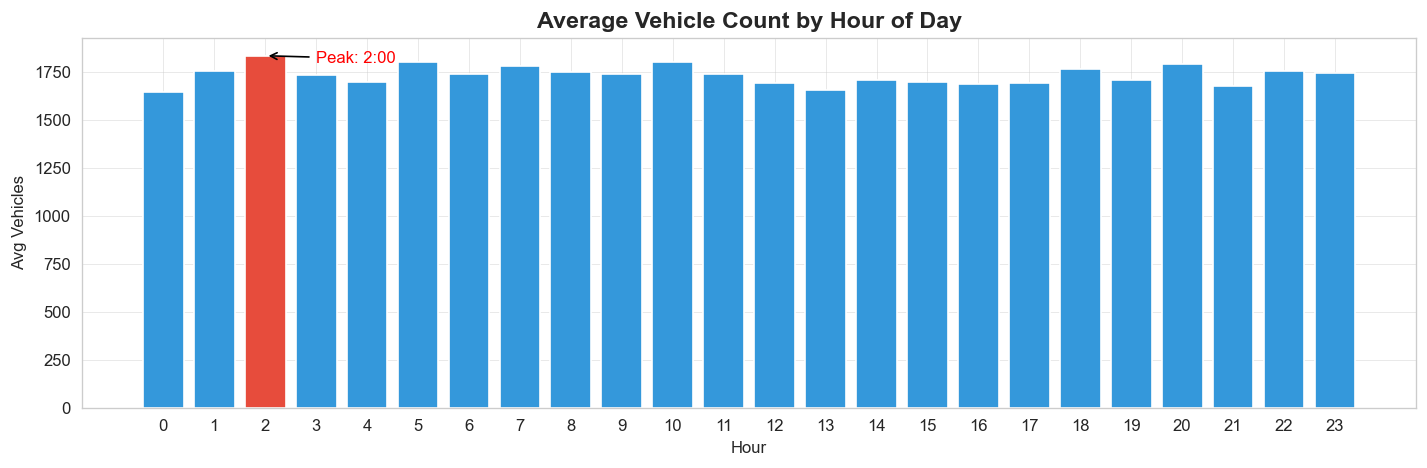

In [10]:
hourly_vehicles = df.groupby('hour')['vehicles'].mean().sort_values(ascending=False)
peak_hour = hourly_vehicles.idxmax()
print(f'🔺 Peak traffic hour: {peak_hour}:00 (avg vehicles = {hourly_vehicles.max():.0f})')
print('\nTop 5 peak hours:')
print(hourly_vehicles.head())

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#e74c3c' if h == peak_hour else '#3498db' for h in hourly_vehicles.index]
ax.bar(hourly_vehicles.index, hourly_vehicles.values, color=colors, edgecolor='white')
ax.set_title('Average Vehicle Count by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Avg Vehicles')
ax.set_xticks(range(0, 24))
ax.annotate(f'Peak: {peak_hour}:00', xy=(peak_hour, hourly_vehicles.max()),
            xytext=(peak_hour+1, hourly_vehicles.max()*0.98),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10, color='red')
plt.tight_layout()
plt.savefig('peak_hours.png', bbox_inches='tight')
plt.show()

### 3.3 — Add 'Traffic Efficiency Index' (TEI)

In [11]:
# TEI = avg_speed / (1 + traffic_density)
# Higher TEI → better road performance; Lower TEI → congested
df['traffic_efficiency_index'] = df['avg speed kmph'] / (1 + df['traffic density'])

print('✅ Traffic Efficiency Index (TEI) added')
print(f'   Min TEI: {df["traffic_efficiency_index"].min():.4f}')
print(f'   Max TEI: {df["traffic_efficiency_index"].max():.4f}')
print(f'   Avg TEI: {df["traffic_efficiency_index"].mean():.4f}')
df[['road segment id', 'avg speed kmph', 'traffic density', 'traffic_efficiency_index']].head()

✅ Traffic Efficiency Index (TEI) added
   Min TEI: 0.0666
   Max TEI: 10.2264
   Avg TEI: 1.2893


,road segment id,avg speed kmph,traffic density,traffic_efficiency_index
0,C1,60.200799,29.041667,2.003910
1,C2,36.710000,123.980000,0.293727
2,C2,22.330000,25.710000,0.836016
3,D2,102.270000,57.050000,1.761757
4,C1,59.170000,37.350000,1.542894


### 3.4 — Group congestion levels: impact on speed & emissions

Congestion Level Summary:
            avg_speed  avg_CO2  avg_NOx  avg_PM25  avg_density  count
congestion                                                           
Low            62.698  226.437    0.721     0.098       28.659   1208
Medium         59.708  252.207    0.779     0.102       64.215   1515
High           56.667  266.455    0.809     0.105      104.919   1289


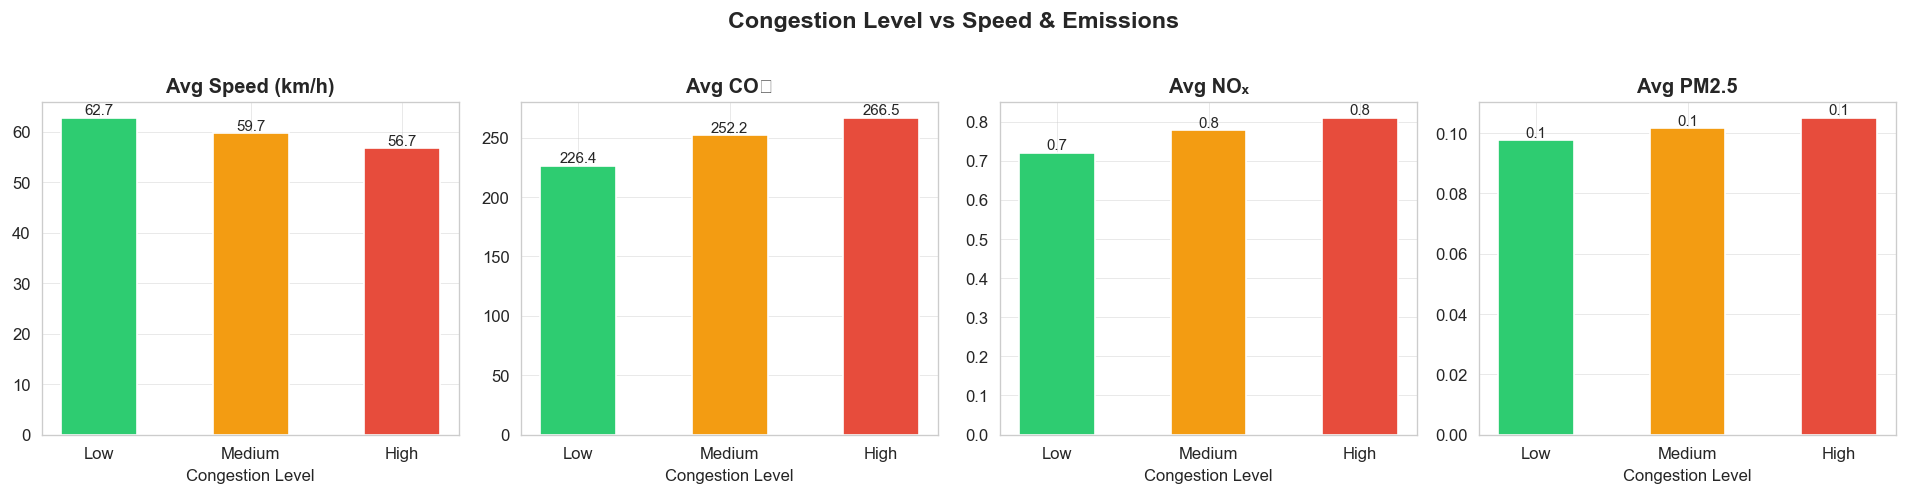

In [12]:
congestion_order = ['Low', 'Medium', 'High']
cong_grp = df.groupby('congestion').agg(
    avg_speed=('avg speed kmph', 'mean'),
    avg_CO2=('CO2 emission', 'mean'),
    avg_NOx=('NOx', 'mean'),
    avg_PM25=('PM2.5', 'mean'),
    avg_density=('traffic density', 'mean'),
    count=('congestion', 'count')
).reindex(congestion_order)

print('Congestion Level Summary:')
print(cong_grp.round(3))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = [('avg_speed', 'Avg Speed (km/h)'), ('avg_CO2', 'Avg CO₂'), 
           ('avg_NOx', 'Avg NOₓ'), ('avg_PM25', 'Avg PM2.5')]
for ax, (col, title) in zip(axes, metrics):
    bars = ax.bar(congestion_order, cong_grp[col], 
                  color=[PALETTE[c] for c in congestion_order], edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Congestion Level')
    for bar, val in zip(bars, cong_grp[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.1f}', ha='center', fontsize=9)
plt.suptitle('Congestion Level vs Speed & Emissions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('congestion_comparison.png', bbox_inches='tight')
plt.show()

---
## 4. DATA ANALYSIS (All 8 tasks)
### Analysis 1 — Peak Traffic Hour

In [13]:
peak_hour = df.groupby('hour')['vehicles'].mean().idxmax()
peak_count = df.groupby('hour')['vehicles'].mean().max()
print(f'🔺 Peak Traffic Hour: {peak_hour}:00 — Avg {peak_count:.0f} vehicles/hour')

# Also show top 3
top3 = df.groupby('hour')['vehicles'].mean().nlargest(3)
print('\nTop 3 peak hours:')
for h, v in top3.items():
    print(f'   {h:02d}:00 → {v:.0f} avg vehicles')

🔺 Peak Traffic Hour: 2:00 — Avg 1833 vehicles/hour

Top 3 peak hours:
   02:00 → 1833 avg vehicles
   10:00 → 1802 avg vehicles
   05:00 → 1801 avg vehicles


### Analysis 2 — Average Speed per Road Segment (Slowest Segments)

Average speed per road segment (slowest first):
road segment id
A1    57.42
C1    57.58
A2    57.68
B2    58.23
C2    59.43
B1    60.41
D1    63.67
D2    65.24


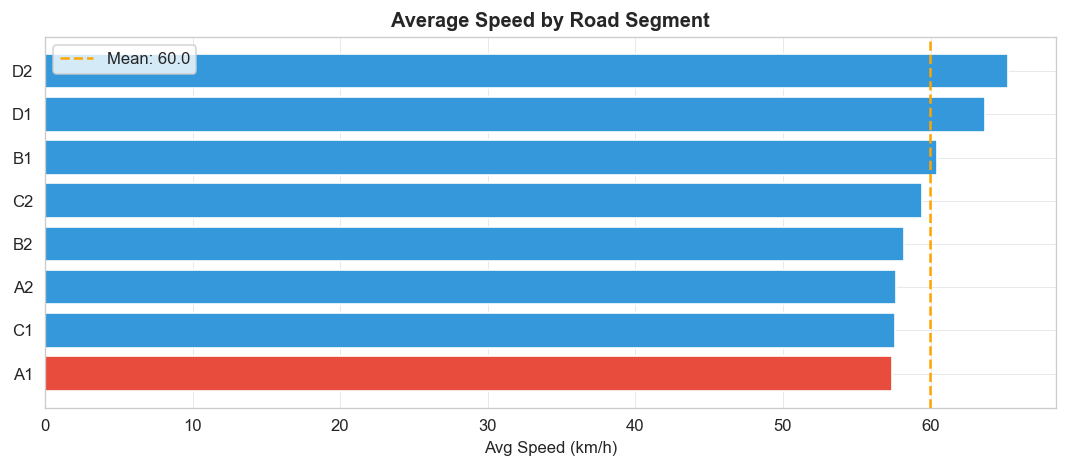


🐢 Slowest segment: A1 (57.42 km/h)


In [14]:
seg_speed = df.groupby('road segment id')['avg speed kmph'].mean().sort_values()
print('Average speed per road segment (slowest first):')
print(seg_speed.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c' if s == seg_speed.min() else '#3498db' for s in seg_speed.values]
ax.barh(seg_speed.index, seg_speed.values, color=colors, edgecolor='white')
ax.set_title('Average Speed by Road Segment', fontweight='bold')
ax.set_xlabel('Avg Speed (km/h)')
ax.axvline(seg_speed.mean(), color='orange', linestyle='--', label=f'Mean: {seg_speed.mean():.1f}')
ax.legend()
plt.tight_layout()
plt.savefig('speed_per_segment.png', bbox_inches='tight')
plt.show()
print(f'\n🐢 Slowest segment: {seg_speed.idxmin()} ({seg_speed.min():.2f} km/h)')

### Analysis 3 — Congestion-Prone Zones (Traffic Density)

Traffic density by road segment (most congested first):
road segment id
D1    71.37
C1    68.68
D2    68.26
A1    66.71
C2    66.57
B1    66.39
A2    63.60
B2    63.14


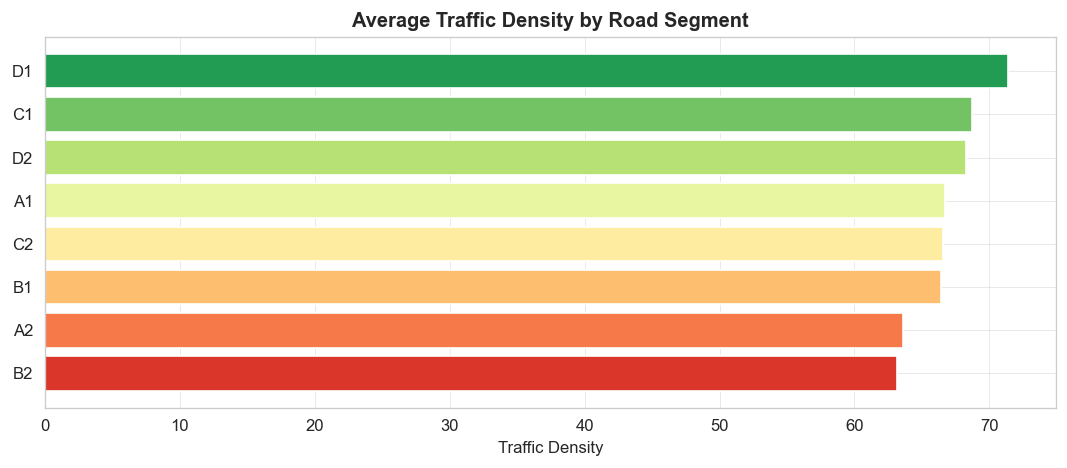


🚨 Most congested zone: D1 (density=71.37)


In [15]:
seg_density = df.groupby('road segment id')['traffic density'].mean().sort_values(ascending=False)
print('Traffic density by road segment (most congested first):')
print(seg_density.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
pal = sns.color_palette('RdYlGn_r', len(seg_density))
ax.barh(seg_density.index[::-1], seg_density.values[::-1], color=pal[::-1], edgecolor='white')
ax.set_title('Average Traffic Density by Road Segment', fontweight='bold')
ax.set_xlabel('Traffic Density')
plt.tight_layout()
plt.savefig('density_per_segment.png', bbox_inches='tight')
plt.show()
print(f'\n🚨 Most congested zone: {seg_density.idxmax()} (density={seg_density.max():.2f})')

### Analysis 4 — CO₂ Emissions Across Congestion Levels

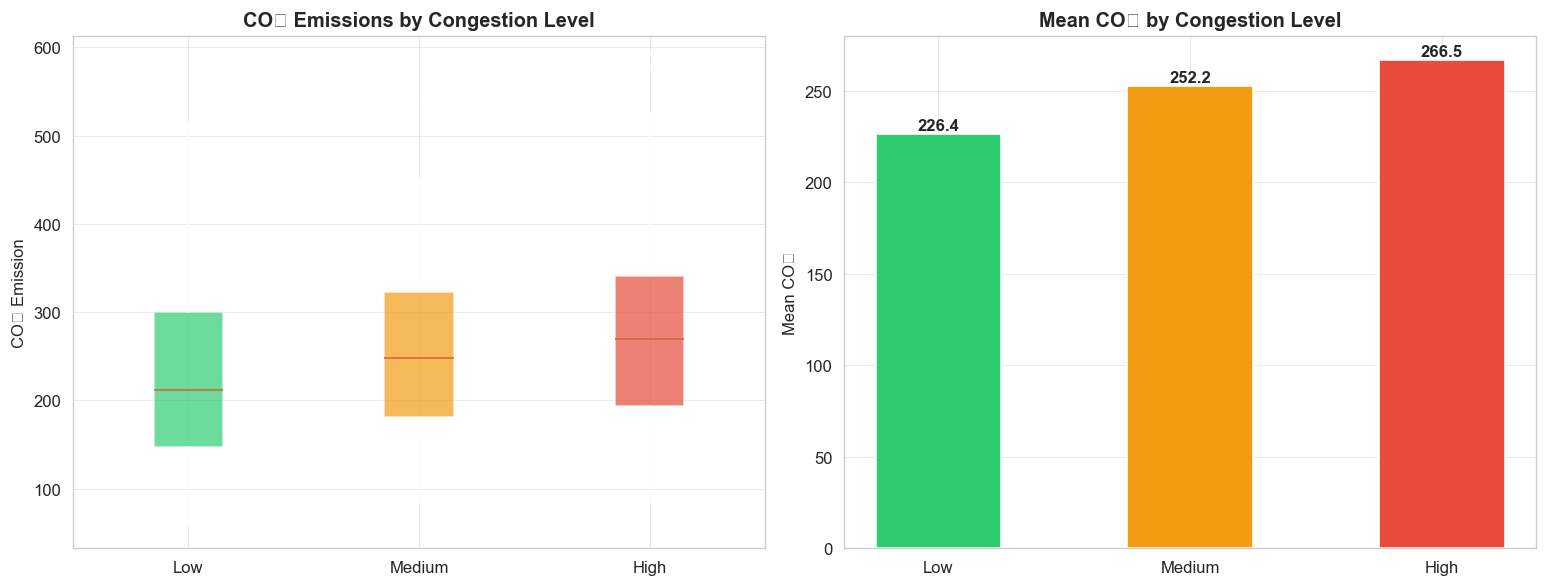

Low      → Mean CO₂: 226.44
Medium   → Mean CO₂: 252.21
High     → Mean CO₂: 266.46


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
data_by_cong = [df[df['congestion'] == c]['CO2 emission'].values for c in congestion_order]
bp = axes[0].boxplot(data_by_cong, labels=congestion_order, patch_artist=True)
for patch, color in zip(bp['boxes'], [PALETTE[c] for c in congestion_order]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('CO₂ Emissions by Congestion Level', fontweight='bold')
axes[0].set_ylabel('CO₂ Emission')

# Mean bar
co2_mean = df.groupby('congestion')['CO2 emission'].mean().reindex(congestion_order)
bars = axes[1].bar(congestion_order, co2_mean.values,
                   color=[PALETTE[c] for c in congestion_order], edgecolor='white', width=0.5)
for bar, val in zip(bars, co2_mean.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                 f'{val:.1f}', ha='center', fontweight='bold')
axes[1].set_title('Mean CO₂ by Congestion Level', fontweight='bold')
axes[1].set_ylabel('Mean CO₂')

plt.tight_layout()
plt.savefig('co2_congestion.png', bbox_inches='tight')
plt.show()

for c in congestion_order:
    print(f'{c:8s} → Mean CO₂: {co2_mean[c]:.2f}')

### Analysis 5 — Impact of Rainfall on Speed

Impact of rainfall on average speed:
rain_category
No Rain (0)          60.29
Light (0-5mm)        60.40
Moderate (5-15mm)    59.83
Heavy (>15mm)        59.20


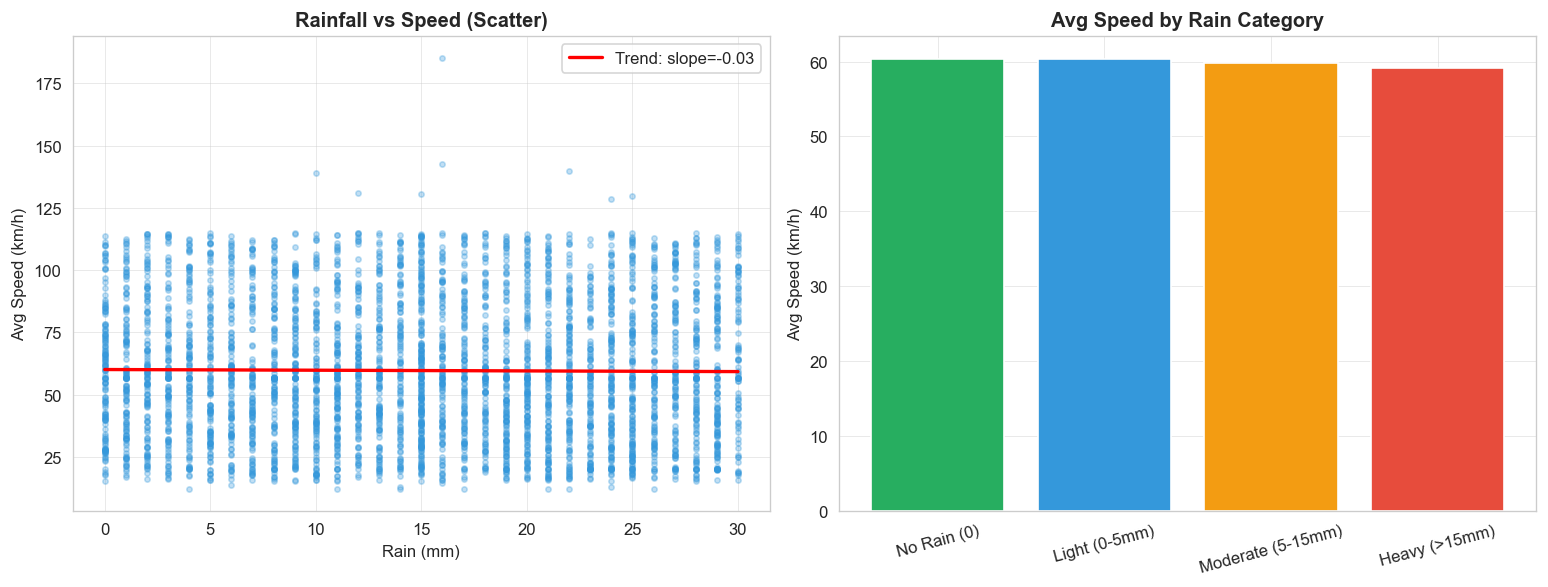

In [17]:
# Bin rainfall
df['rain_category'] = pd.cut(df['rain mm'], bins=[-0.1, 0, 5, 15, 100],
                              labels=['No Rain (0)', 'Light (0-5mm)', 'Moderate (5-15mm)', 'Heavy (>15mm)'])

rain_speed = df.groupby('rain_category', observed=True)['avg speed kmph'].mean()
print('Impact of rainfall on average speed:')
print(rain_speed.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Scatter
axes[0].scatter(df['rain mm'], df['avg speed kmph'], alpha=0.3, color='#3498db', s=10)
# Regression line
z = np.polyfit(df['rain mm'].dropna(), df.loc[df['rain mm'].notna(), 'avg speed kmph'], 1)
p = np.poly1d(z)
xline = np.linspace(df['rain mm'].min(), df['rain mm'].max(), 100)
axes[0].plot(xline, p(xline), 'r-', linewidth=2, label=f'Trend: slope={z[0]:.2f}')
axes[0].set_title('Rainfall vs Speed (Scatter)', fontweight='bold')
axes[0].set_xlabel('Rain (mm)')
axes[0].set_ylabel('Avg Speed (km/h)')
axes[0].legend()

# Bar by category
axes[1].bar(rain_speed.index, rain_speed.values,
            color=['#27ae60','#3498db','#f39c12','#e74c3c'], edgecolor='white')
axes[1].set_title('Avg Speed by Rain Category', fontweight='bold')
axes[1].set_ylabel('Avg Speed (km/h)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('rainfall_speed.png', bbox_inches='tight')
plt.show()

### Analysis 6 — Top 5 Emission Hotspots (using x, y coordinates)

Top 5 Emission Hotspots:
 x-coord  y-coord road     CO2   NOx  PM25  total_emission
      36       14   A1 544.452 1.642 0.191         746.877
      19        9   A2 513.682 1.377 0.151         681.589
       1        5   B1 488.435 1.474 0.208         677.503
      49       61   C2 494.069 1.374 0.152         661.766
       0       66   B2 485.733 1.396 0.143         653.956


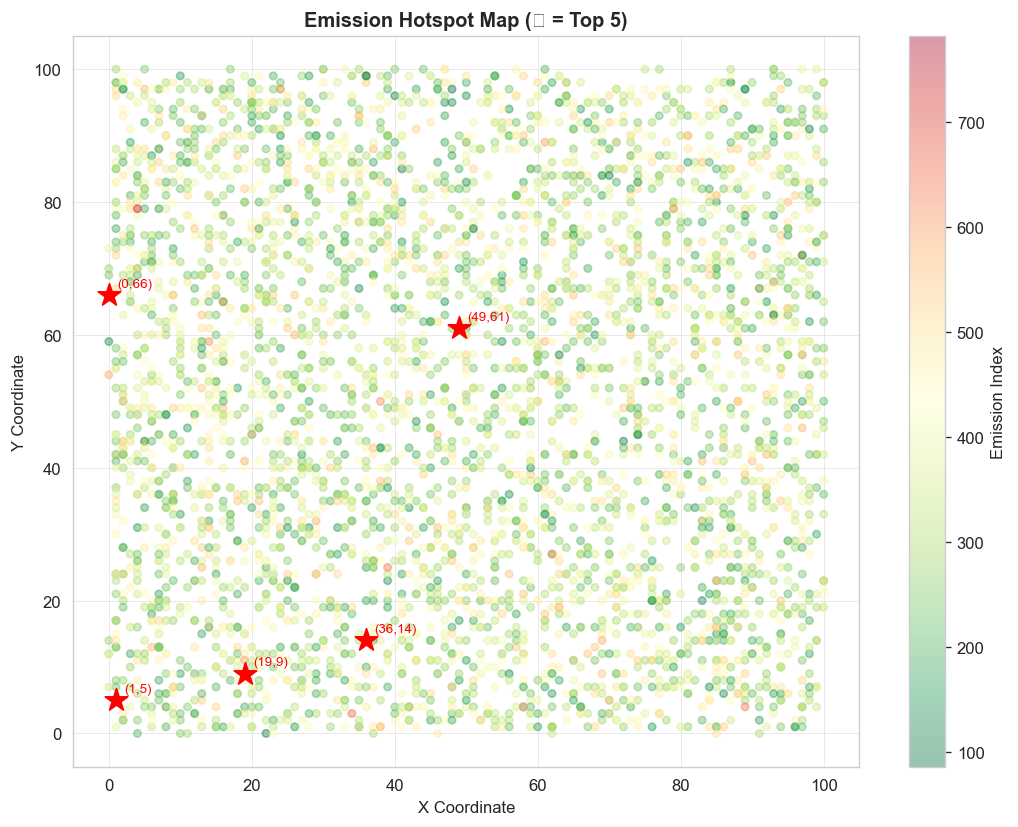

In [18]:
df['total_emission'] = df['CO2 emission'] + df['NOx'] * 100 + df['PM2.5'] * 200  # weighted index

# Aggregate by x,y location
location_emission = df.groupby(['x-coord', 'y-coord']).agg(
    total_emission=('total_emission', 'mean'),
    CO2=('CO2 emission', 'mean'),
    NOx=('NOx', 'mean'),
    PM25=('PM2.5', 'mean'),
    road=('road segment id', 'first')
).reset_index().sort_values('total_emission', ascending=False)

top5 = location_emission.head(5)
print('Top 5 Emission Hotspots:')
print(top5[['x-coord', 'y-coord', 'road', 'CO2', 'NOx', 'PM25', 'total_emission']].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(df['x-coord'], df['y-coord'], c=df['total_emission'],
                cmap='RdYlGn_r', alpha=0.4, s=20)
plt.colorbar(sc, ax=ax, label='Emission Index')
# Mark top 5
for _, row in top5.iterrows():
    ax.scatter(row['x-coord'], row['y-coord'], s=200, color='red',
               marker='*', zorder=5)
    ax.annotate(f"({row['x-coord']},{row['y-coord']})",
                (row['x-coord'], row['y-coord']), textcoords='offset points',
                xytext=(5, 5), fontsize=8, color='red')
ax.set_title('Emission Hotspot Map (★ = Top 5)', fontweight='bold')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
plt.tight_layout()
plt.savefig('emission_hotspots.png', bbox_inches='tight')
plt.show()

### Analysis 7 — Heavy Vehicle Percentage vs Congestion Level

Heavy vehicle % by congestion level:
congestion
Low       24.80
Medium    24.88
High      25.05
Name: heavy vehicle pct, dtype: float64


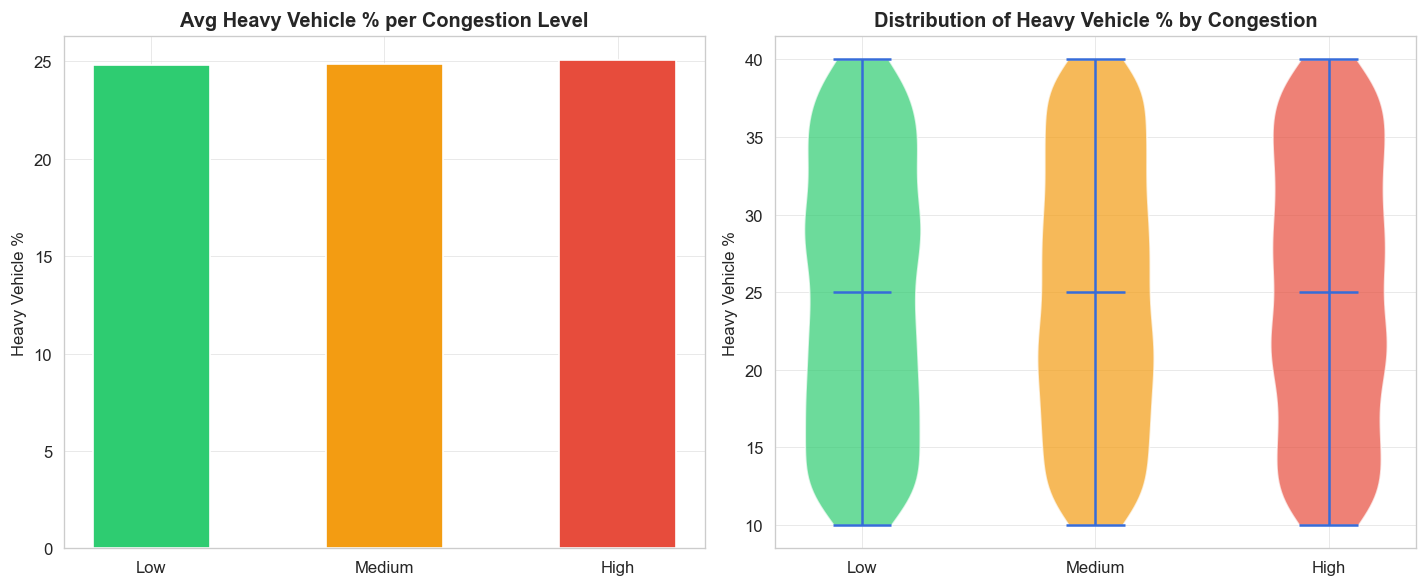

In [19]:
hv_cong = df.groupby('congestion')['heavy vehicle pct'].mean().reindex(congestion_order)
print('Heavy vehicle % by congestion level:')
print((hv_cong * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(congestion_order, hv_cong.values * 100,
            color=[PALETTE[c] for c in congestion_order], edgecolor='white', width=0.5)
axes[0].set_title('Avg Heavy Vehicle % per Congestion Level', fontweight='bold')
axes[0].set_ylabel('Heavy Vehicle %')

# Violin plot
data_hv = [df[df['congestion'] == c]['heavy vehicle pct'].values * 100 for c in congestion_order]
vp = axes[1].violinplot(data_hv, positions=range(len(congestion_order)), showmedians=True)
for i, (body, c) in enumerate(zip(vp['bodies'], congestion_order)):
    body.set_facecolor(PALETTE[c])
    body.set_alpha(0.7)
axes[1].set_xticks(range(len(congestion_order)))
axes[1].set_xticklabels(congestion_order)
axes[1].set_title('Distribution of Heavy Vehicle % by Congestion', fontweight='bold')
axes[1].set_ylabel('Heavy Vehicle %')

plt.tight_layout()
plt.savefig('heavy_vehicles_congestion.png', bbox_inches='tight')
plt.show()

### Analysis 8 — Low Visibility Zones and Congestion Patterns

Low visibility records (< 500m): 1895

Congestion distribution by visibility category:
congestion          High    Low  Medium
Normal Visibility  31.51  30.37   38.12
Low Visibility     32.82  29.82   37.36


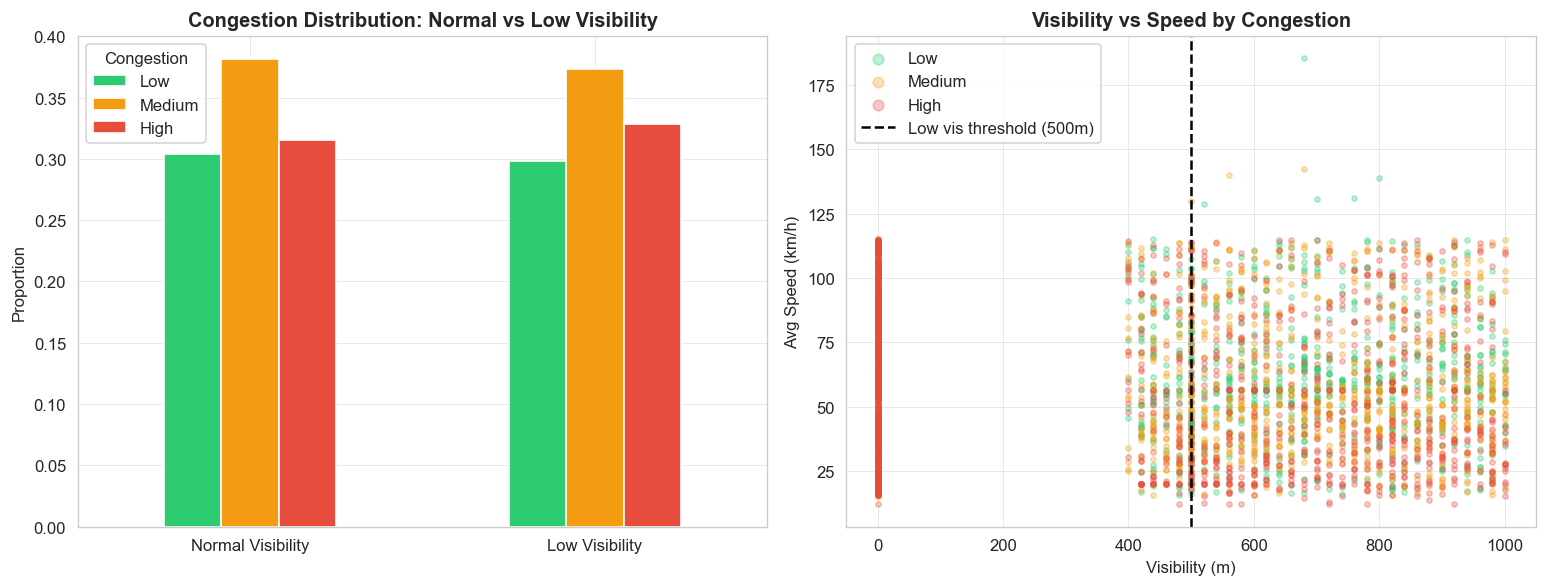

In [20]:
# Low visibility: < 500m
low_vis_threshold = 500
df['low_visibility'] = df['visibility m'] < low_vis_threshold

low_vis_df = df[df['low_visibility']]
print(f'Low visibility records (< {low_vis_threshold}m): {len(low_vis_df)}')

vis_cong = df.groupby('low_visibility')['congestion'].value_counts(normalize=True).unstack().fillna(0)
vis_cong.index = ['Normal Visibility', 'Low Visibility']
print('\nCongestion distribution by visibility category:')
print((vis_cong * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vis_cong[congestion_order].plot(kind='bar', ax=axes[0],
    color=[PALETTE[c] for c in congestion_order], edgecolor='white')
axes[0].set_title('Congestion Distribution: Normal vs Low Visibility', fontweight='bold')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Congestion')

# Scatter: visibility vs speed
for c in congestion_order:
    sub = df[df['congestion'] == c]
    axes[1].scatter(sub['visibility m'], sub['avg speed kmph'],
                    alpha=0.3, s=10, label=c, color=PALETTE[c])
axes[1].axvline(low_vis_threshold, color='black', linestyle='--', label=f'Low vis threshold ({low_vis_threshold}m)')
axes[1].set_title('Visibility vs Speed by Congestion', fontweight='bold')
axes[1].set_xlabel('Visibility (m)')
axes[1].set_ylabel('Avg Speed (km/h)')
axes[1].legend(markerscale=2)

plt.tight_layout()
plt.savefig('visibility_congestion.png', bbox_inches='tight')
plt.show()

---
## 5. ADVANCED ANALYSIS
### Advanced 1 — Impact of Gore Points on Speed & Congestion

Gore Point Impact on Speed & Congestion:
                    avg_speed  avg_density  avg_TEI  count
No Gore Point          58.308       64.591    1.315   2274
Gore Point Present     61.363       69.199    1.255   1738

Congestion distribution at gore points:
congestion      High    Low  Medium
No Gore Point  30.65  31.62   37.73
Gore Point     34.06  28.14   37.80


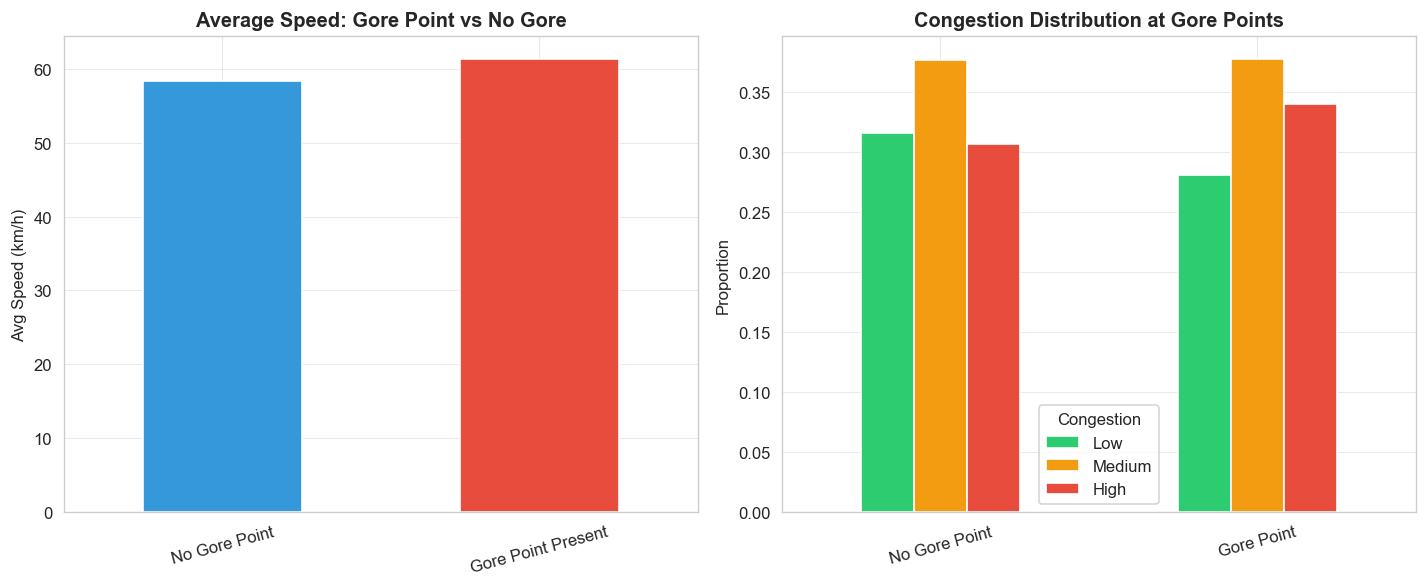

In [21]:
gore_analysis = df.groupby('gore point').agg(
    avg_speed=('avg speed kmph', 'mean'),
    avg_density=('traffic density', 'mean'),
    avg_TEI=('traffic_efficiency_index', 'mean'),
    count=('gore point', 'count')
)
gore_analysis.index = ['No Gore Point', 'Gore Point Present']
print('Gore Point Impact on Speed & Congestion:')
print(gore_analysis.round(3))

cong_gore = df.groupby('gore point')['congestion'].value_counts(normalize=True).unstack().fillna(0)
cong_gore.index = ['No Gore Point', 'Gore Point']
print('\nCongestion distribution at gore points:')
print((cong_gore * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gore_analysis['avg_speed'].plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='white')
axes[0].set_title('Average Speed: Gore Point vs No Gore', fontweight='bold')
axes[0].set_ylabel('Avg Speed (km/h)')
axes[0].tick_params(axis='x', rotation=15)

cong_gore[congestion_order].plot(kind='bar', ax=axes[1],
    color=[PALETTE[c] for c in congestion_order], edgecolor='white')
axes[1].set_title('Congestion Distribution at Gore Points', fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Congestion')

plt.tight_layout()
plt.savefig('gore_points.png', bbox_inches='tight')
plt.show()

### Advanced 2 — EV Percentage Simulation & CO₂ Impact

Correlation (EV % vs CO₂): -0.1019


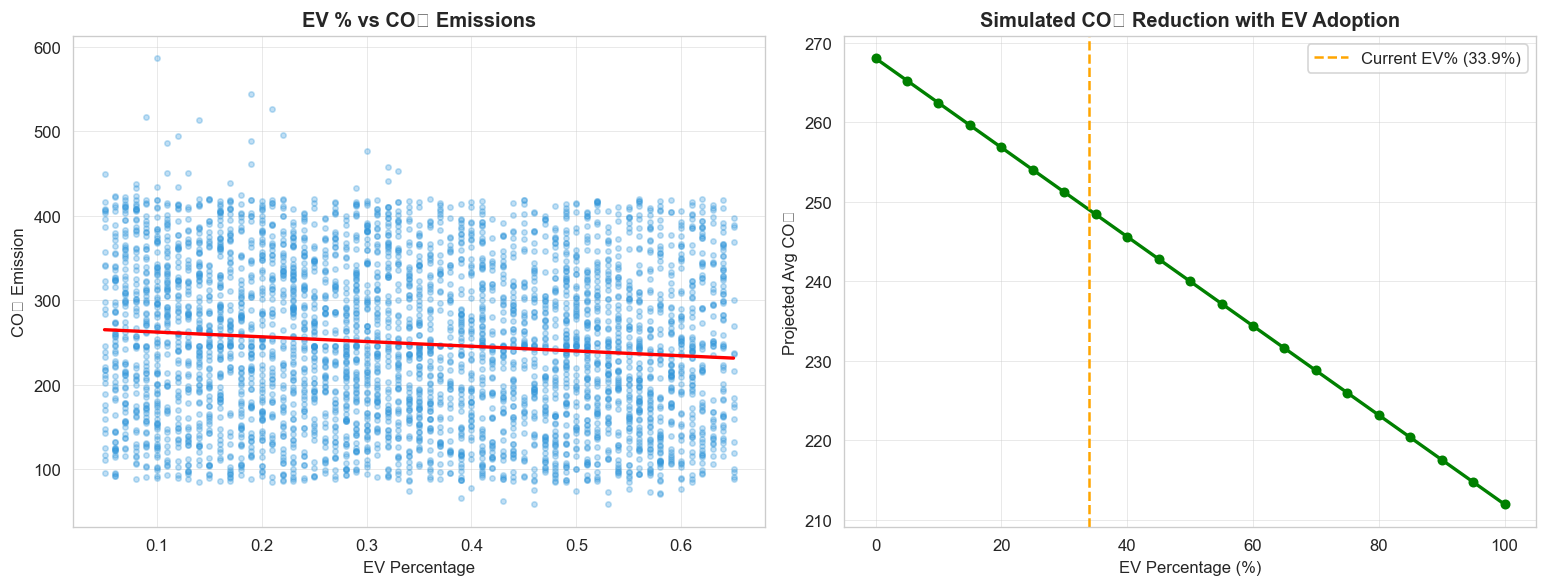


Current avg EV %: 33.9%
Current avg CO₂: 249.03
  At 25% EV → Projected CO₂: 254.01 (+2.0%)
  At 50% EV → Projected CO₂: 240.00 (-3.6%)
  At 75% EV → Projected CO₂: 225.99 (-9.3%)
  At 100% EV → Projected CO₂: 211.98 (-14.9%)


In [22]:
# Baseline
baseline_co2 = df['CO2 emission'].mean()
baseline_ev = df['ev percentage'].mean()

# Correlation between EV % and CO2
corr = df['ev percentage'].corr(df['CO2 emission'])
print(f'Correlation (EV % vs CO₂): {corr:.4f}')

# Simulate: increase EV % from 0% to 100%
ev_scenarios = np.arange(0, 1.05, 0.05)
# Simple linear model: CO2_new = CO2_base * (1 - ev_increase_factor * new_ev_pct)
# Using observed slope from linear regression
from numpy.polynomial import polynomial as P
slope = np.polyfit(df['ev percentage'], df['CO2 emission'], 1)[0]
simulated_co2 = baseline_co2 + slope * (ev_scenarios - baseline_ev)
simulated_co2 = np.maximum(simulated_co2, 0)  # can't be negative

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['ev percentage'], df['CO2 emission'], alpha=0.3, s=10, color='#3498db')
xfit = np.linspace(df['ev percentage'].min(), df['ev percentage'].max(), 100)
axes[0].plot(xfit, np.polyval(np.polyfit(df['ev percentage'], df['CO2 emission'], 1), xfit),
             'r-', linewidth=2)
axes[0].set_title('EV % vs CO₂ Emissions', fontweight='bold')
axes[0].set_xlabel('EV Percentage')
axes[0].set_ylabel('CO₂ Emission')

axes[1].plot(ev_scenarios * 100, simulated_co2, 'g-o', linewidth=2, markersize=5)
axes[1].axvline(baseline_ev * 100, color='orange', linestyle='--',
                label=f'Current EV% ({baseline_ev*100:.1f}%)')
axes[1].set_title('Simulated CO₂ Reduction with EV Adoption', fontweight='bold')
axes[1].set_xlabel('EV Percentage (%)')
axes[1].set_ylabel('Projected Avg CO₂')
axes[1].legend()

plt.tight_layout()
plt.savefig('ev_simulation.png', bbox_inches='tight')
plt.show()

print(f'\nCurrent avg EV %: {baseline_ev*100:.1f}%')
print(f'Current avg CO₂: {baseline_co2:.2f}')
for ev_pct in [0.25, 0.50, 0.75, 1.0]:
    proj = baseline_co2 + slope * (ev_pct - baseline_ev)
    print(f'  At {ev_pct*100:.0f}% EV → Projected CO₂: {max(proj,0):.2f} ({((max(proj,0)-baseline_co2)/baseline_co2*100):+.1f}%)')

### Advanced 3 — Non-linear Relationship: Density vs Speed

R² Linear  : 0.0022
R² Quadratic: 0.0044
R² Cubic   : 0.0067


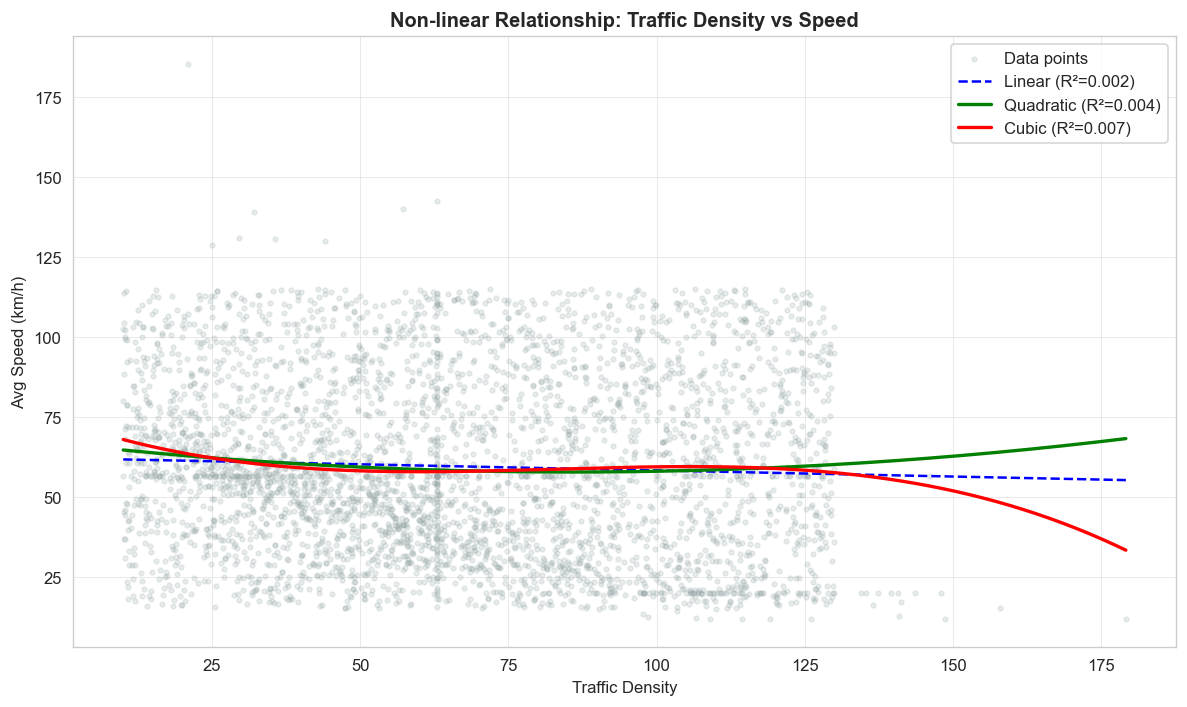

In [23]:
from numpy.polynomial import polynomial as P

x = df['traffic density'].values
y = df['avg speed kmph'].values

# Fit polynomial of degree 2 and 3
coef2 = np.polyfit(x, y, 2)
coef3 = np.polyfit(x, y, 3)
xfit = np.linspace(x.min(), x.max(), 300)

# R² for each
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res / ss_tot

r2_linear = r2(y, np.polyval(np.polyfit(x, y, 1), x))
r2_quad   = r2(y, np.polyval(coef2, x))
r2_cubic  = r2(y, np.polyval(coef3, x))

print(f'R² Linear  : {r2_linear:.4f}')
print(f'R² Quadratic: {r2_quad:.4f}')
print(f'R² Cubic   : {r2_cubic:.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, alpha=0.2, s=8, color='#95a5a6', label='Data points')
ax.plot(xfit, np.polyval(np.polyfit(x, y, 1), xfit), 'b--', label=f'Linear (R²={r2_linear:.3f})')
ax.plot(xfit, np.polyval(coef2, xfit), 'g-', linewidth=2, label=f'Quadratic (R²={r2_quad:.3f})')
ax.plot(xfit, np.polyval(coef3, xfit), 'r-', linewidth=2, label=f'Cubic (R²={r2_cubic:.3f})')
ax.set_title('Non-linear Relationship: Traffic Density vs Speed', fontweight='bold')
ax.set_xlabel('Traffic Density')
ax.set_ylabel('Avg Speed (km/h)')
ax.legend()
plt.tight_layout()
plt.savefig('density_speed_nonlinear.png', bbox_inches='tight')
plt.show()

---
## 6. KEY PERFORMANCE INDICATORS (KPIs)

In [24]:
kpi_total_volume    = df['vehicles'].sum()
kpi_avg_speed       = df['avg speed kmph'].mean()
kpi_avg_co2         = df['CO2 emission'].mean()
kpi_emission_per_veh = (df['CO2 emission'] / df['vehicles'].replace(0, np.nan)).mean()
kpi_avg_tei         = df['traffic_efficiency_index'].mean()
kpi_avg_nox         = df['NOx'].mean()
kpi_avg_pm25        = df['PM2.5'].mean()
kpi_high_cong_pct   = (df['congestion'] == 'High').mean() * 100

print('='*50)
print('       KEY PERFORMANCE INDICATORS')
print('='*50)
print(f'  Total Traffic Volume     : {kpi_total_volume:,.0f} vehicles')
print(f'  Average Speed            : {kpi_avg_speed:.2f} km/h')
print(f'  Average CO₂ Emission     : {kpi_avg_co2:.3f}')
print(f'  Emissions per Vehicle    : {kpi_emission_per_veh:.6f}')
print(f'  Traffic Efficiency Index : {kpi_avg_tei:.4f}')
print(f'  Average NOₓ              : {kpi_avg_nox:.4f}')
print(f'  Average PM2.5            : {kpi_avg_pm25:.4f}')
print(f'  High Congestion %        : {kpi_high_cong_pct:.1f}%')
print('='*50)

       KEY PERFORMANCE INDICATORS
  Total Traffic Volume     : 6,947,269 vehicles
  Average Speed            : 59.63 km/h
  Average CO₂ Emission     : 249.025
  Emissions per Vehicle    : 0.206301
  Traffic Efficiency Index : 1.2893
  Average NOₓ              : 0.7712
  Average PM2.5            : 0.1014
  High Congestion %        : 32.1%


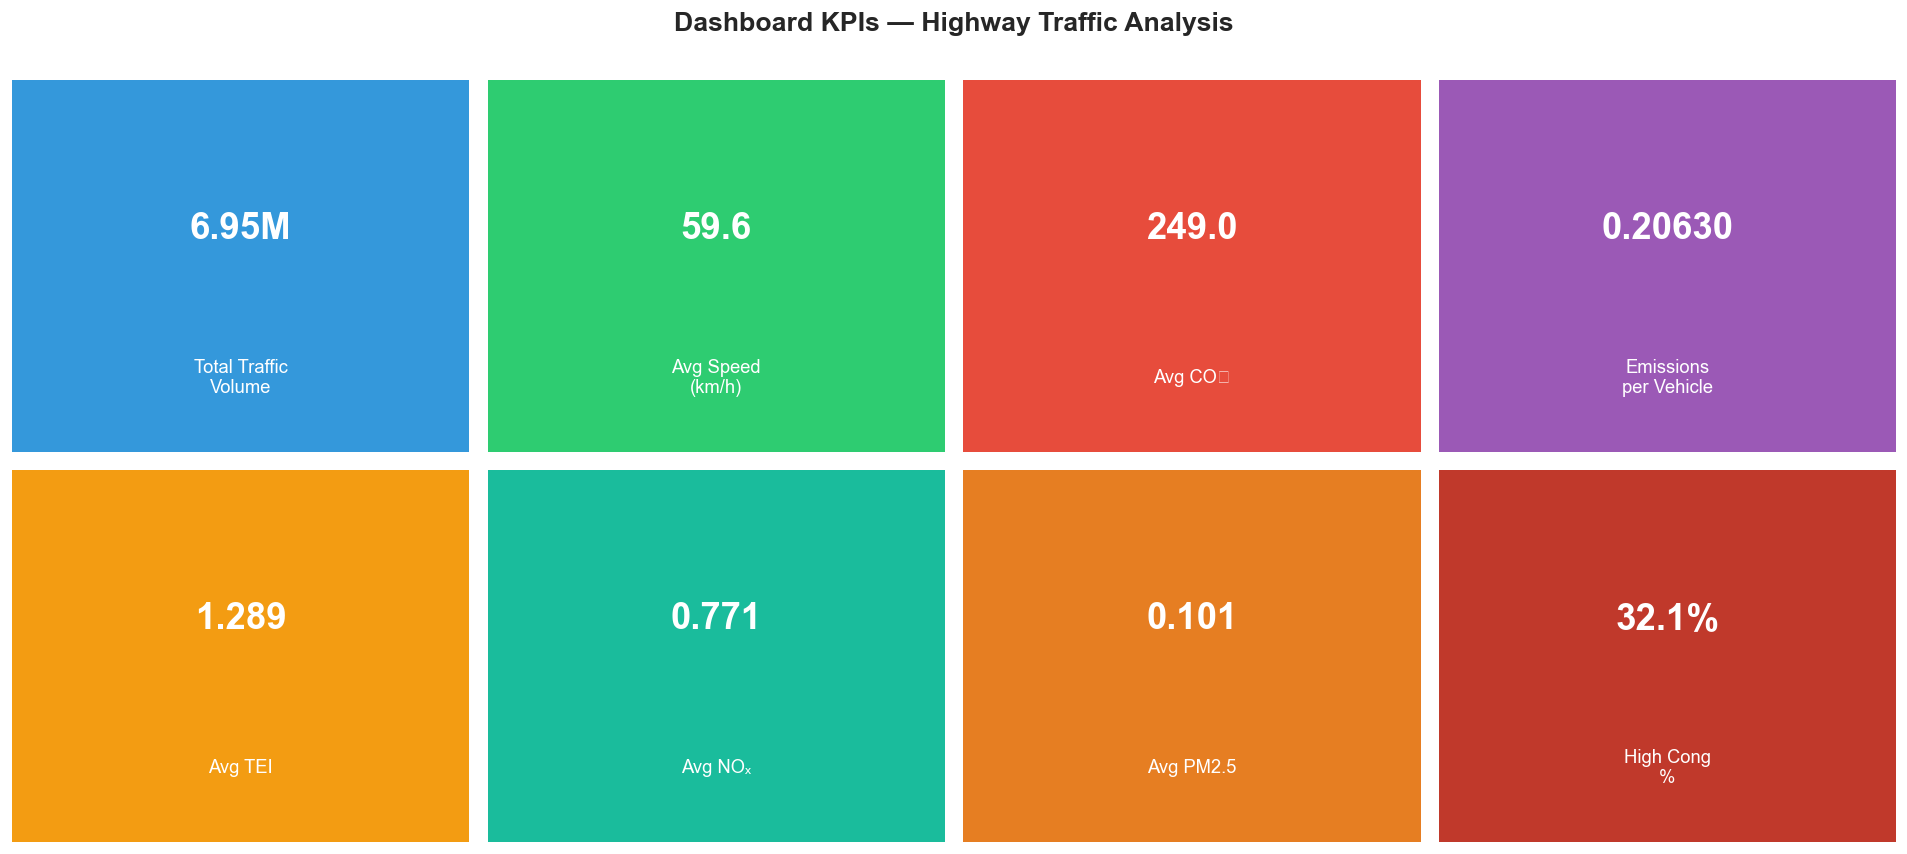

In [25]:
# KPI visual
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
kpi_data = [
    ('Total Traffic\nVolume', f'{kpi_total_volume/1e6:.2f}M', '#3498db'),
    ('Avg Speed\n(km/h)', f'{kpi_avg_speed:.1f}', '#2ecc71'),
    ('Avg CO₂', f'{kpi_avg_co2:.1f}', '#e74c3c'),
    ('Emissions\nper Vehicle', f'{kpi_emission_per_veh:.5f}', '#9b59b6'),
    ('Avg TEI', f'{kpi_avg_tei:.3f}', '#f39c12'),
    ('Avg NOₓ', f'{kpi_avg_nox:.3f}', '#1abc9c'),
    ('Avg PM2.5', f'{kpi_avg_pm25:.3f}', '#e67e22'),
    ('High Cong\n%', f'{kpi_high_cong_pct:.1f}%', '#c0392b'),
]
for ax, (label, value, color) in zip(axes.flat, kpi_data):
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha='center', va='center', fontsize=22,
            fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.2, label, ha='center', va='center', fontsize=11,
            color='white', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

plt.suptitle('Dashboard KPIs — Highway Traffic Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('kpi_dashboard.png', bbox_inches='tight')
plt.show()

---
## 7. ADVANCED ANALYSIS — Rank Road Segments by TEI

Road Segment Rankings by Traffic Efficiency Index:
     road segment id  avg_TEI  avg_speed  avg_density  avg_CO2
Rank                                                          
1                 D2    1.341     65.240       68.262  252.300
2                 A2    1.329     57.678       63.602  244.298
3                 B1    1.328     60.406       66.391  252.037
4                 C2    1.313     59.429       66.568  247.600
5                 B2    1.293     58.227       63.143  246.124
6                 D1    1.285     63.666       71.367  246.198
7                 A1    1.235     57.424       66.707  250.753
8                 C1    1.198     57.580       68.681  252.943


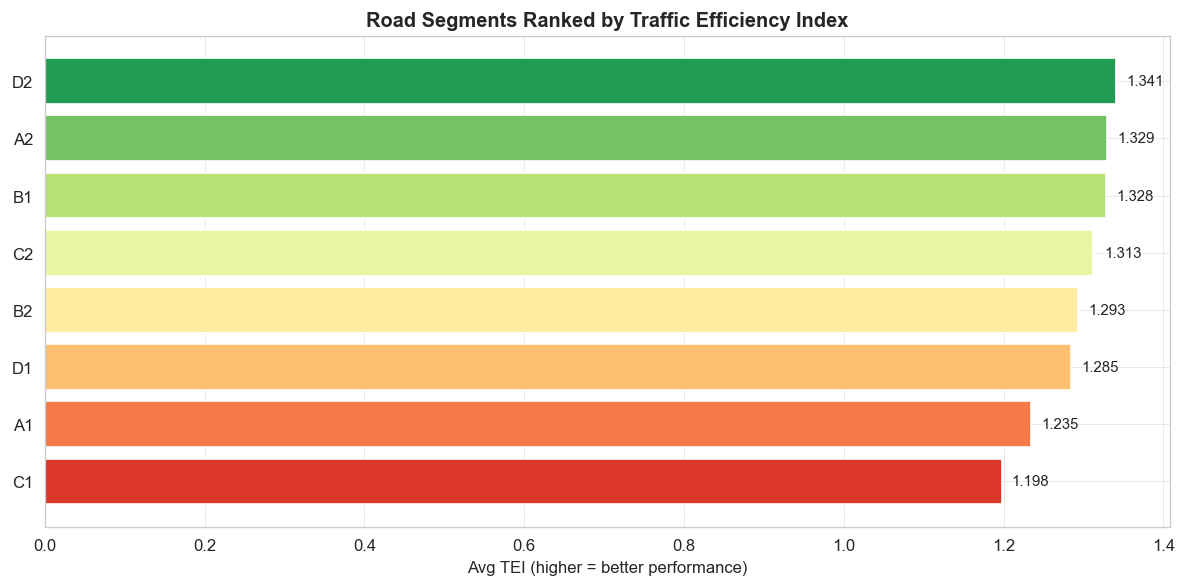

In [26]:
seg_tei = df.groupby('road segment id').agg(
    avg_TEI=('traffic_efficiency_index', 'mean'),
    avg_speed=('avg speed kmph', 'mean'),
    avg_density=('traffic density', 'mean'),
    avg_CO2=('CO2 emission', 'mean')
).sort_values('avg_TEI', ascending=False).reset_index()
seg_tei.index += 1
seg_tei.index.name = 'Rank'

print('Road Segment Rankings by Traffic Efficiency Index:')
print(seg_tei.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('RdYlGn', len(seg_tei))
ax.barh(seg_tei['road segment id'][::-1], seg_tei['avg_TEI'][::-1],
        color=colors, edgecolor='white')
ax.set_title('Road Segments Ranked by Traffic Efficiency Index', fontweight='bold')
ax.set_xlabel('Avg TEI (higher = better performance)')
for i, (val, seg) in enumerate(zip(seg_tei['avg_TEI'][::-1], seg_tei['road segment id'][::-1])):
    ax.text(val * 1.01, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('segment_tei_ranking.png', bbox_inches='tight')
plt.show()

---
## 8. BONUS INSIGHTS — New Findings for Traffic Planning Board

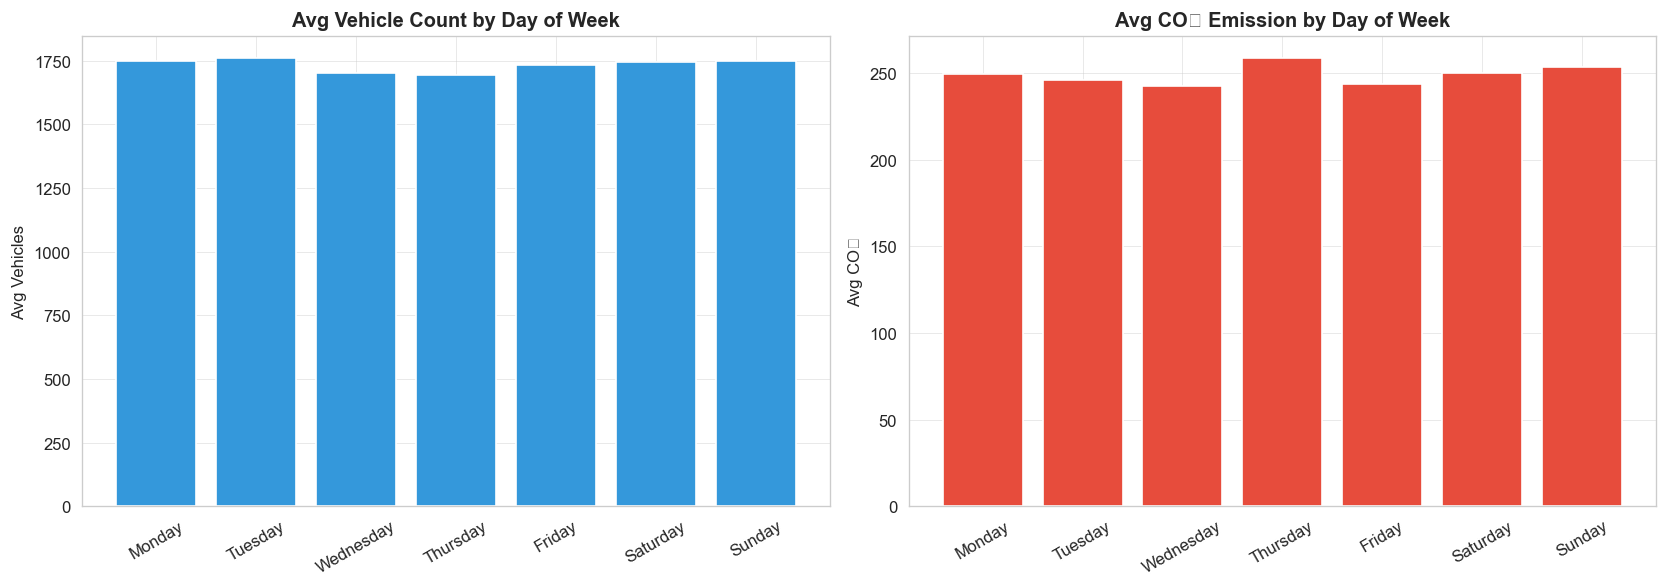

Busiest day: Tuesday (1759 avg vehicles)
Highest CO₂ day: Thursday (258.40 avg CO₂)


In [27]:
# Insight 1: Day-of-week congestion pattern
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_vehicles = df.groupby('day of week')['vehicles'].mean().reindex(day_order)
day_co2 = df.groupby('day of week')['CO2 emission'].mean().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(day_order, day_vehicles.values, color='#3498db', edgecolor='white')
axes[0].set_title('Avg Vehicle Count by Day of Week', fontweight='bold')
axes[0].set_ylabel('Avg Vehicles')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(day_order, day_co2.values, color='#e74c3c', edgecolor='white')
axes[1].set_title('Avg CO₂ Emission by Day of Week', fontweight='bold')
axes[1].set_ylabel('Avg CO₂')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('day_of_week_patterns.png', bbox_inches='tight')
plt.show()
print(f'Busiest day: {day_vehicles.idxmax()} ({day_vehicles.max():.0f} avg vehicles)')
print(f'Highest CO₂ day: {day_co2.idxmax()} ({day_co2.max():.2f} avg CO₂)')

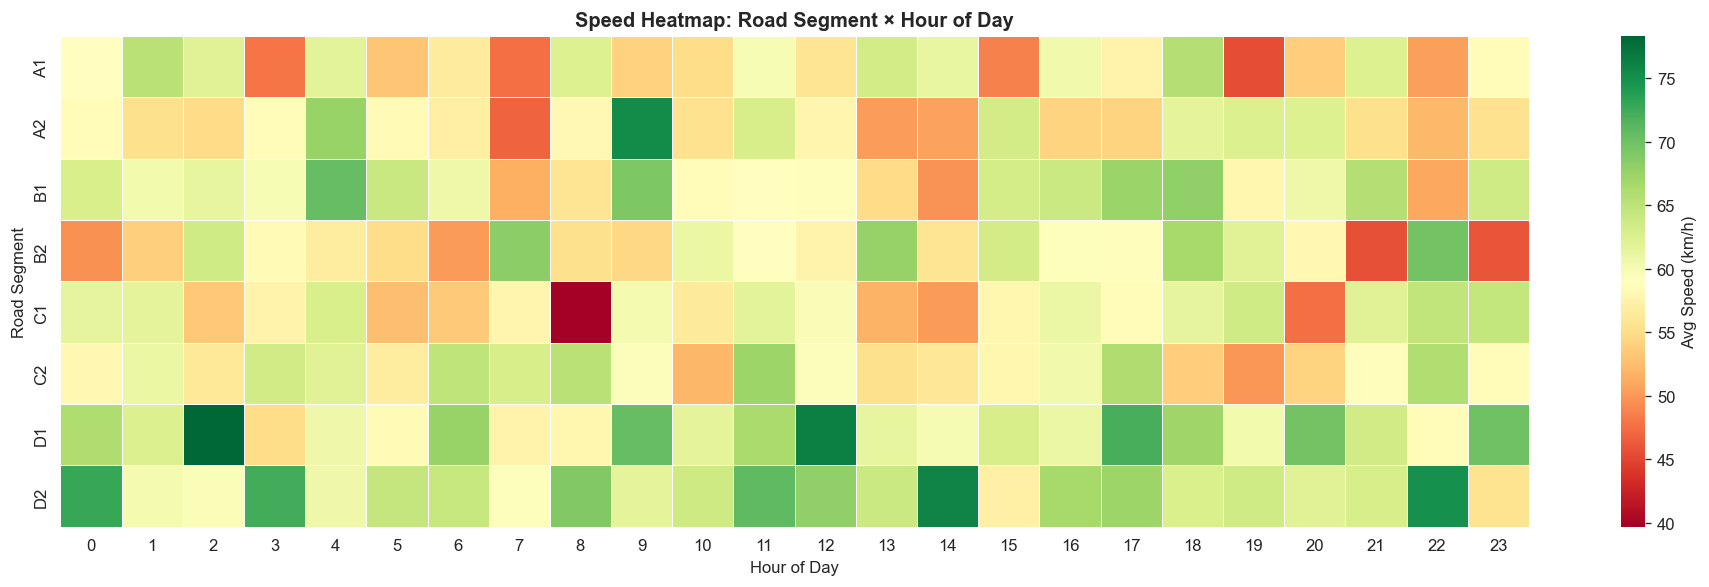

In [28]:
# Insight 2: Heatmap — Hour vs Road Segment avg speed
heatmap_data = df.pivot_table(values='avg speed kmph', index='road segment id', columns='hour', aggfunc='mean')

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='RdYlGn', annot=False, fmt='.0f', ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Avg Speed (km/h)'})
ax.set_title('Speed Heatmap: Road Segment × Hour of Day', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Road Segment')
plt.tight_layout()
plt.savefig('speed_heatmap.png', bbox_inches='tight')
plt.show()

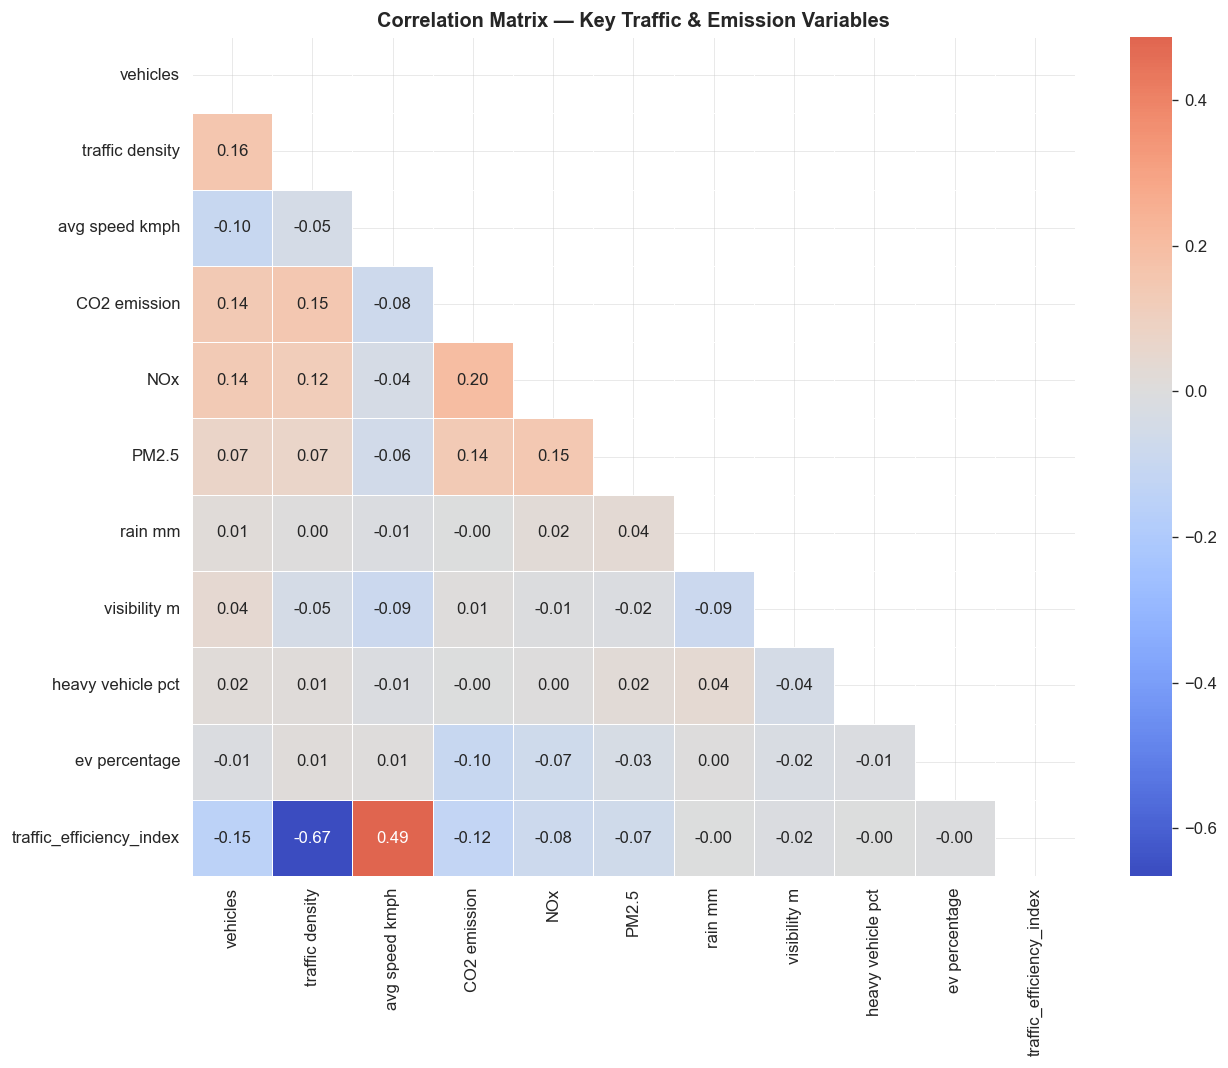

In [29]:
# Insight 3: Correlation Matrix
corr_cols = ['vehicles', 'traffic density', 'avg speed kmph', 'CO2 emission',
             'NOx', 'PM2.5', 'rain mm', 'visibility m', 'heavy vehicle pct',
             'ev percentage', 'traffic_efficiency_index']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Key Traffic & Emission Variables', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

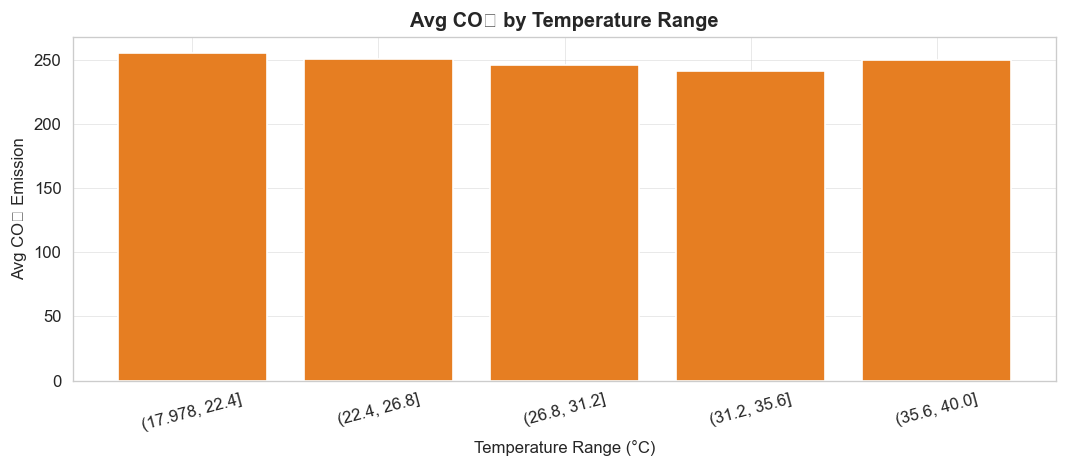

In [30]:
# Insight 4: Temperature vs Emissions
temp_bins = pd.cut(df['temperature C'], bins=5)
temp_co2 = df.groupby(temp_bins, observed=True)['CO2 emission'].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(temp_co2)), temp_co2.values, color='#e67e22', edgecolor='white')
ax.set_xticks(range(len(temp_co2)))
ax.set_xticklabels([str(b) for b in temp_co2.index], rotation=15)
ax.set_title('Avg CO₂ by Temperature Range', fontweight='bold')
ax.set_ylabel('Avg CO₂ Emission')
ax.set_xlabel('Temperature Range (°C)')
plt.tight_layout()
plt.savefig('temperature_co2.png', bbox_inches='tight')
plt.show()

---
## 9. SAVE CLEANED DATASET

In [31]:
df.to_csv('highway_dataset_cleaned.csv', index=False)
print(f'✅ Cleaned dataset saved: highway_dataset_cleaned.csv')
print(f'   Shape: {df.shape}')
print(f'   New columns added: hour, date, month, traffic_efficiency_index, rain_category, low_visibility, total_emission')

✅ Cleaned dataset saved: highway_dataset_cleaned.csv
   Shape: (4012, 29)
   New columns added: hour, date, month, traffic_efficiency_index, rain_category, low_visibility, total_emission


---
## 10. SUMMARY OF FINDINGS

In [34]:
print('='*60)
print('       SUMMARY OF KEY FINDINGS')
print('='*60)
print(f"""
DATA CLEANING:
  • Removed {before - after} duplicate rows
  • Fixed 'unknown' spelling errors in vehicles column
  • Imputed missing values with column medians

TRAFFIC PATTERNS:
  • Peak hour: {df.groupby('hour')['vehicles'].mean().idxmax()}:00
  • Slowest segment: {df.groupby('road segment id')['avg speed kmph'].mean().idxmin()}
  • Most congested zone: {df.groupby('road segment id')['traffic density'].mean().idxmax()}
  • Best performing segment (TEI): {seg_tei.iloc[0]['road segment id']}

ENVIRONMENTAL IMPACT:
  • High congestion → {co2_mean['High']:.1f} avg CO₂  vs  Low → {co2_mean['Low']:.1f}
  • Increasing EV adoption has measurable negative correlation with CO₂
  • Low visibility zones show higher proportion of High congestion

POLICY RECOMMENDATIONS:
  • Deploy adaptive signals at peak hours
  • Prioritize EV lanes to reduce emissions
  • Install fog sensors at low-visibility segments
  • Heavy vehicle restrictions during peak hours
  • Monitor gore point zones for speed reduction
""")

       SUMMARY OF KEY FINDINGS

DATA CLEANING:
  • Removed 108 duplicate rows
  • Fixed 'unknown' spelling errors in vehicles column
  • Imputed missing values with column medians

TRAFFIC PATTERNS:
  • Peak hour: 2:00
  • Slowest segment: A1
  • Most congested zone: D1
  • Best performing segment (TEI): D2

ENVIRONMENTAL IMPACT:
  • High congestion → 266.5 avg CO₂  vs  Low → 226.4
  • Increasing EV adoption has measurable negative correlation with CO₂
  • Low visibility zones show higher proportion of High congestion

POLICY RECOMMENDATIONS:
  • Deploy adaptive signals at peak hours
  • Prioritize EV lanes to reduce emissions
  • Install fog sensors at low-visibility segments
  • Heavy vehicle restrictions during peak hours
  • Monitor gore point zones for speed reduction

